# Project 5B: Flow Matching from Scratch!

## Setup environment

In [1]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.5 MB/s eta 0:00:00


In [2]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [3]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.AvgPool2d(kernel_size=7),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0),
            nn.BatchNorm2d(in_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## Implementing Unconditional UNet

In [4]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        D = num_hiddens

        # Encoder
        self.enc0 = ConvBlock(in_channels, D)   # 1x28x28 -> D x 28 x 28
        self.down1 = DownBlock(D, D)            # D x 28 x 28 -> D x 14 x 14
        self.down2 = DownBlock(D, 2 * D)        # D x 14 x 14 -> 2D x 7 x 7

        # Bottleneck
        self.flatten = Flatten()                # 2D x 7 x 7 -> 2D x 1 x 1
        self.unflatten = Unflatten(2 * D)       # 2D x 1 x 1 -> 2D x 7 x 7

        # Decoder
        self.up1 = UpBlock(4 * D, D)           # concat(2D,2D)=4D at 7x7 -> D x 14 x 14
        self.up2 = UpBlock(2 * D, D)           # concat(D,D)=2D at 14x14 -> D x 28 x 28

        # Final refinement after last concat
        self.out_block = ConvBlock(2 * D, D)   # concat(D,D)=2D at 28x28 -> D x 28 x 28
        self.out = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Encoder
        x0 = self.enc0(x)          # (N, D, 28, 28)
        x1 = self.down1(x0)        # (N, D, 14, 14)
        x2 = self.down2(x1)        # (N, 2D, 7, 7)

        # Bottleneck
        z = self.flatten(x2)       # (N, 2D, 1, 1)
        z = self.unflatten(z)      # (N, 2D, 7, 7)

        # Decoder + skip connections
        z = torch.cat([z, x2], dim=1)   # (N, 4D, 7, 7)
        z = self.up1(z)                 # (N, D, 14, 14)

        z = torch.cat([z, x1], dim=1)   # (N, 2D, 14, 14)
        z = self.up2(z)                 # (N, D, 28, 28)

        z = torch.cat([z, x0], dim=1)   # (N, 2D, 28, 28)
        z = self.out_block(z)           # (N, D, 28, 28)

        z = self.out(z)                 # (N, in_channels, 28, 28)
        return z

# Part 1.2: Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


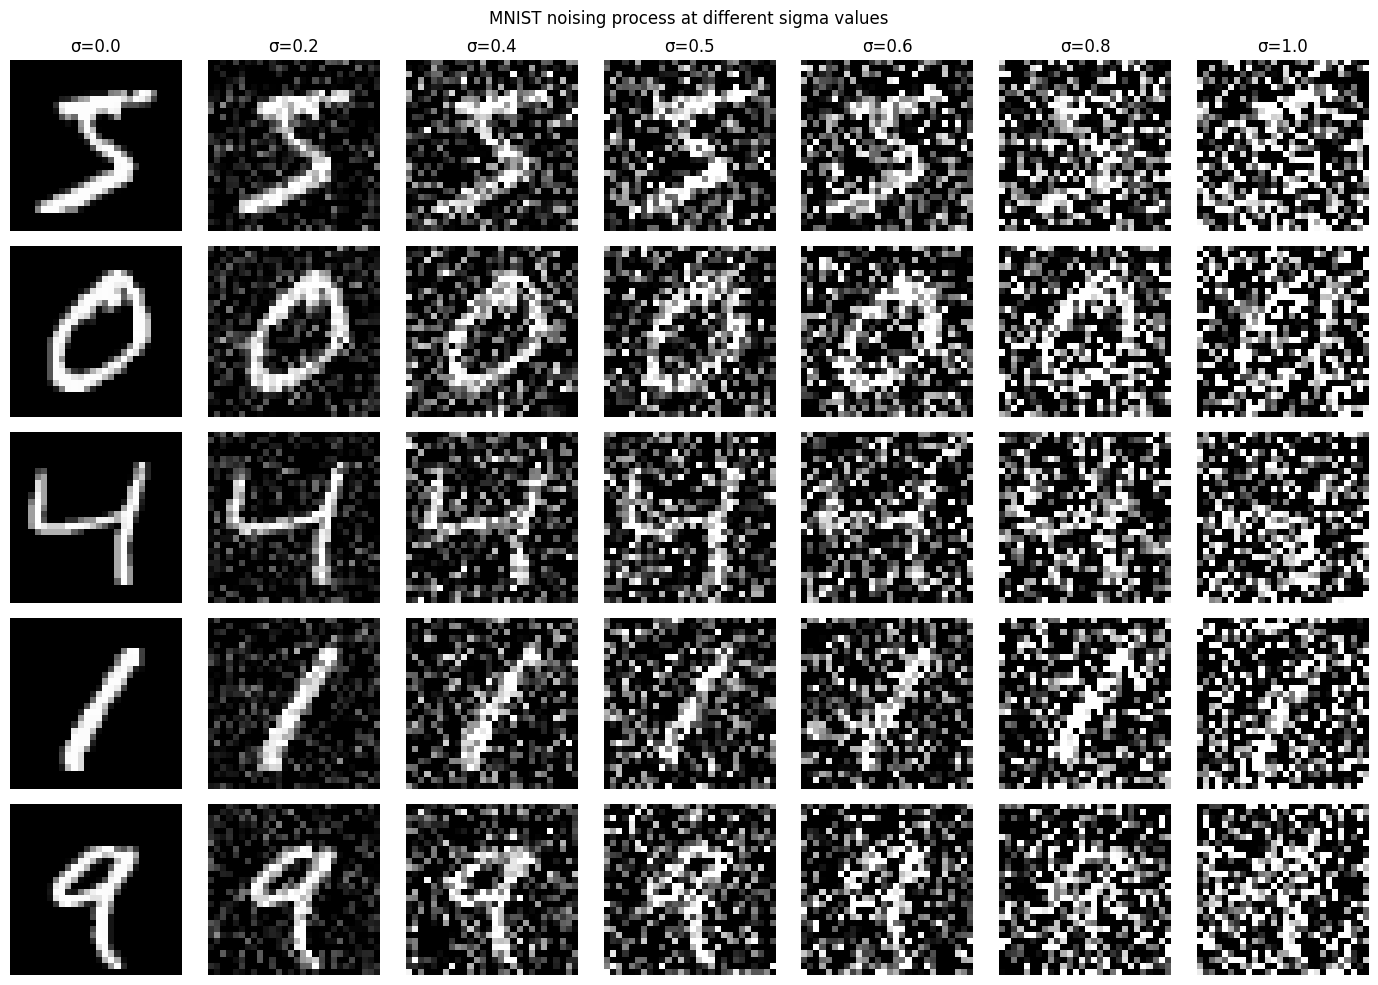

In [5]:
# Visualize images at different noisy levels
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
images = [train_dataset[i][0] for i in range(5)]

fig, axes = plt.subplots(len(images), len(sigmas), figsize=(14, 10))

for i, img in enumerate(images):
    for j, sigma in enumerate(sigmas):
        noisy_img = img + torch.randn_like(img) * sigma
        noisy_img = torch.clamp(noisy_img, 0.0, 1.0)
        axes[i, j].imshow(noisy_img.squeeze(), cmap='gray')
        if i == 0:
            axes[i, j].set_title(f"σ={sigma}")
        axes[i, j].axis('off')

plt.suptitle("MNIST noising process at different sigma values")
plt.tight_layout()
plt.show()

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set your hyperparameters
batch_size = 64
learning_rate = 1e-3
noise_level = 0.5
hidden_dim = 64
num_epochs = 5

In [7]:
# Define your datasets and dataloaders
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
# Define your model, optimizer, and loss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

In [9]:
# The training loops
train_losses = []
denoiser_snapshots = {}

for epoch in range(num_epochs):
    model.train()
    for i, (images, _) in enumerate(tqdm(train_loader, desc=f"Denoiser Epoch {epoch+1}/{num_epochs}")):
        images = images.to(device)

        noise = torch.randn_like(images) * noise_level
        noisy_images = torch.clamp(images + noise, 0.0, 1.0)

        outputs = model(noisy_images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    if epoch + 1 in [1, 5]:
        model.eval()
        with torch.no_grad():
            test_images, _ = next(iter(test_loader))
            test_images = test_images[:8].to(device)
            test_noisy = torch.clamp(test_images + torch.randn_like(test_images) * noise_level, 0.0, 1.0)
            test_denoised = model(test_noisy)

        denoiser_snapshots[epoch + 1] = (
            test_images.cpu(),
            test_noisy.cpu(),
            test_denoised.cpu()
        )

Denoiser Epoch 5/5: 100%|██████████| 938/938 [00:08<00:00, 111.17it/s]


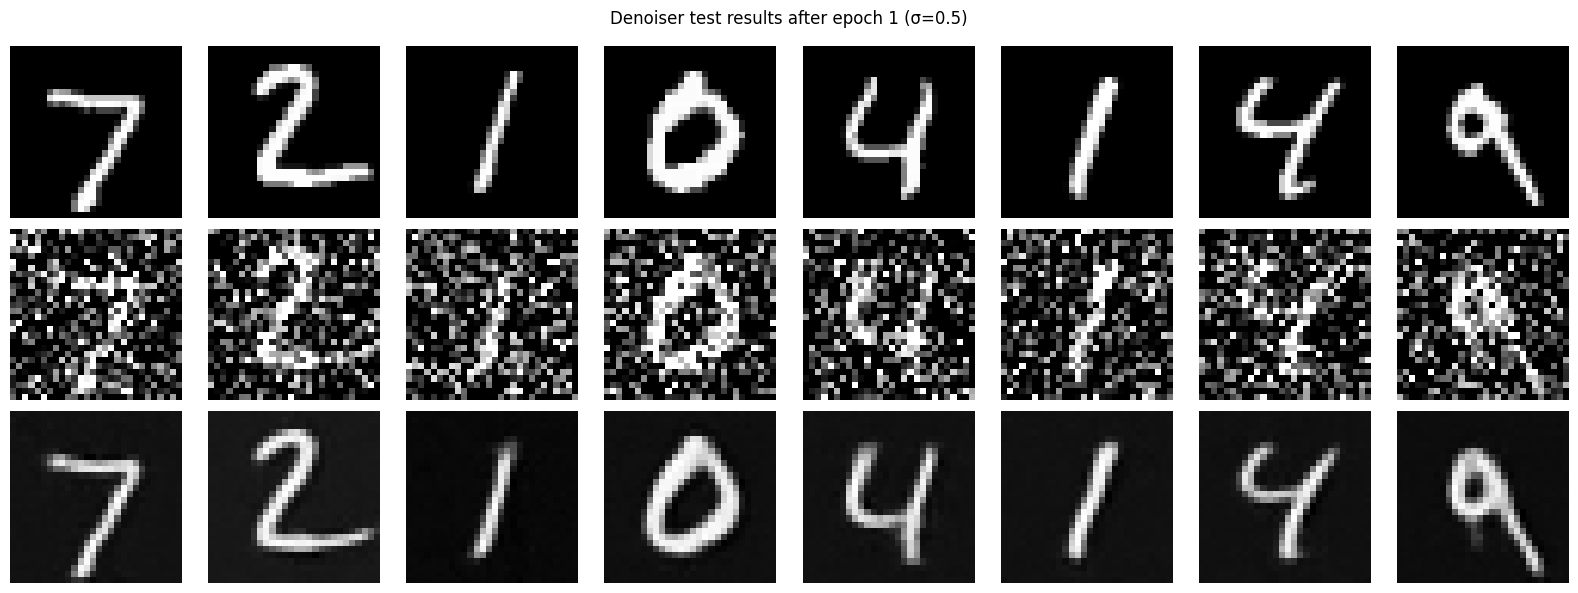

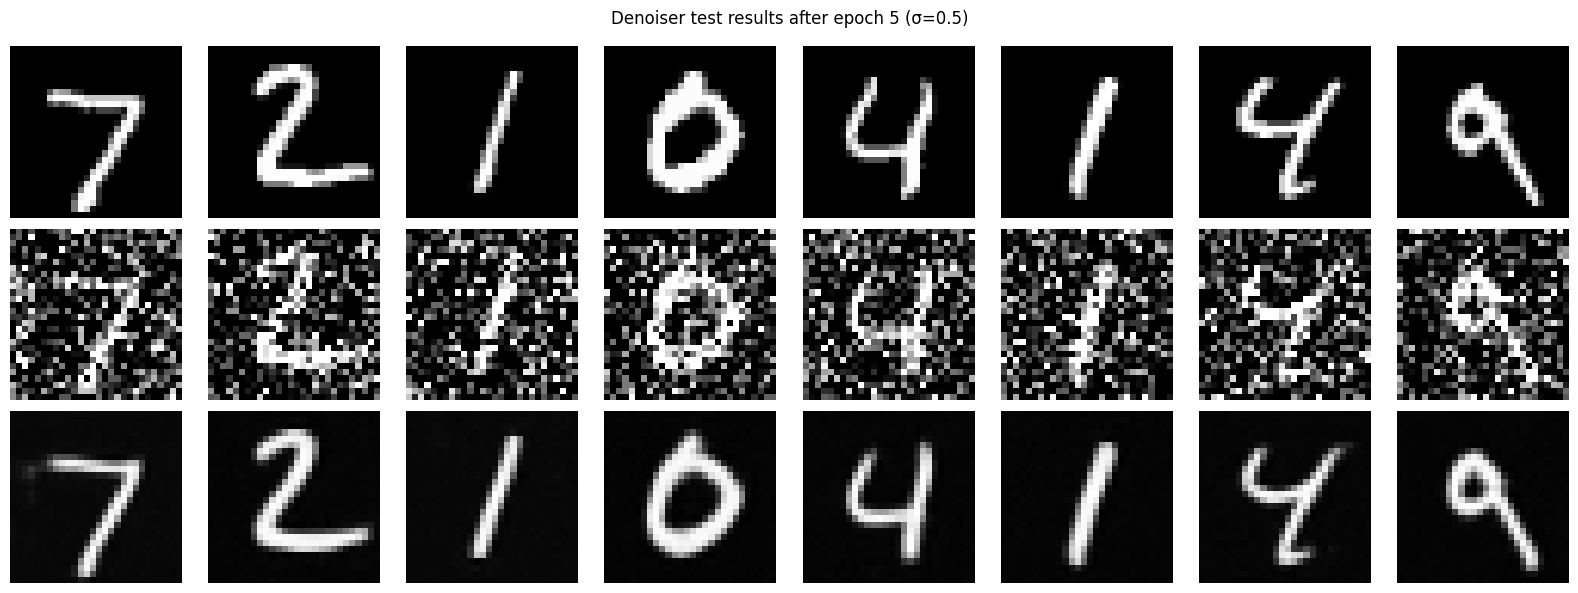

In [10]:
# Visualize denoiser test results after epoch 1 and 5
for ep in [1, 5]:
    clean, noisy, denoised = denoiser_snapshots[ep]

    fig, axes = plt.subplots(3, 8, figsize=(16, 6))
    for i in range(8):
        axes[0, i].imshow(clean[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel("Clean", fontsize=12)

        axes[1, i].imshow(noisy[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel("Noisy", fontsize=12)

        axes[2, i].imshow(denoised[i].squeeze(), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_ylabel("Denoised", fontsize=12)

    plt.suptitle(f"Denoiser test results after epoch {ep} (σ=0.5)")
    plt.tight_layout()
    plt.show()

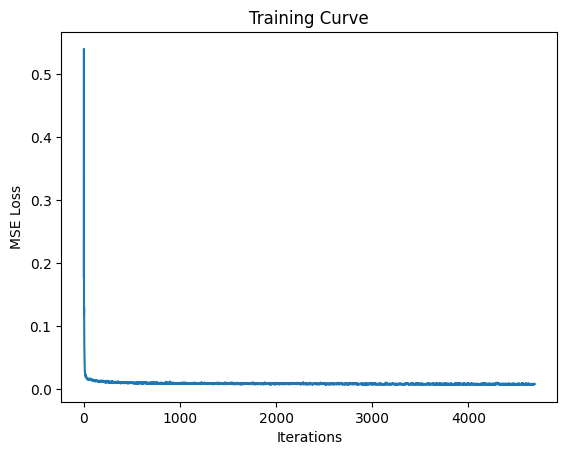

In [11]:
# Visualize your training curve
plt.plot(train_losses)
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Training Curve')
plt.show()

## Part 1.2.2: Out-of-Distribution Testing

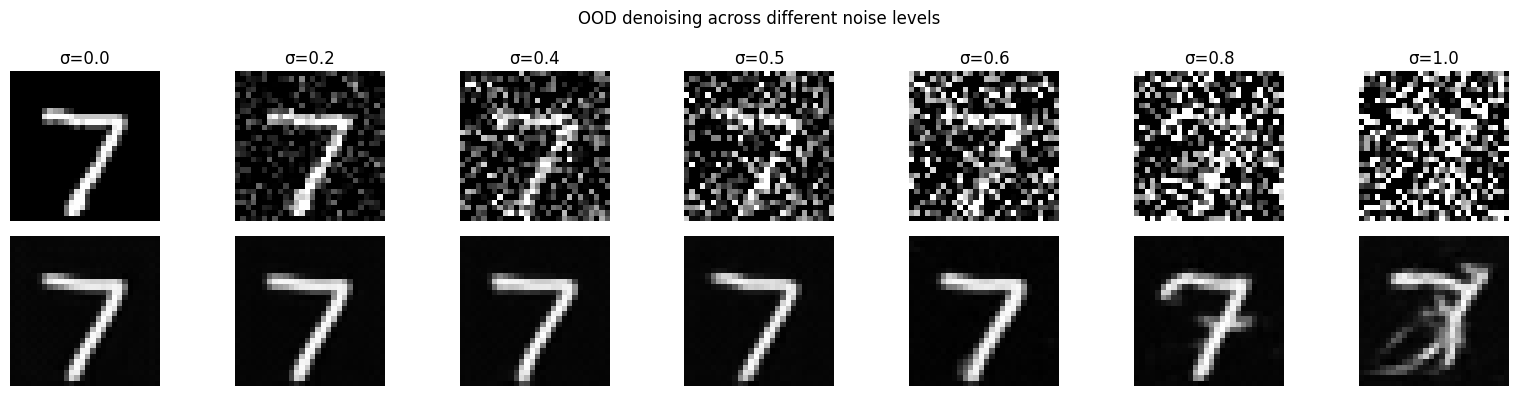

In [12]:
# Visualize OOD testing with the same image across different sigma values
model.eval()

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
test_images, _ = next(iter(test_loader))
base_img = test_images[0:1].to(device)  # same image

fig, axes = plt.subplots(2, len(sigmas), figsize=(16, 4))

with torch.no_grad():
    for j, sigma in enumerate(sigmas):
        noisy_img = torch.clamp(base_img + torch.randn_like(base_img) * sigma, 0.0, 1.0)
        denoised_img = model(noisy_img)

        axes[0, j].imshow(noisy_img[0].cpu().squeeze(), cmap='gray')
        axes[0, j].set_title(f"σ={sigma}")
        axes[0, j].axis('off')

        axes[1, j].imshow(denoised_img[0].cpu().squeeze(), cmap='gray')
        axes[1, j].axis('off')

axes[0, 0].set_ylabel("Noisy", fontsize=12)
axes[1, 0].set_ylabel("Denoised", fontsize=12)
plt.suptitle("OOD denoising across different noise levels")
plt.tight_layout()
plt.show()

## Part 1.2.3 Denoising Pure Noise

In [13]:
# Feel free to use code from part 1.2.1
# as they should be very similar

# Part 1.2.3 Denoising Pure Noise

pure_model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
pure_optimizer = torch.optim.Adam(pure_model.parameters(), lr=learning_rate)
pure_criterion = nn.MSELoss()

pure_train_losses = []
pure_snapshots = {}

for epoch in range(num_epochs):
    pure_model.train()
    for images, _ in tqdm(train_loader, desc=f"Pure-noise Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)

        pure_noise = torch.randn_like(images)
        outputs = pure_model(pure_noise)

        loss = pure_criterion(outputs, images)

        pure_optimizer.zero_grad()
        loss.backward()
        pure_optimizer.step()

        pure_train_losses.append(loss.item())

    if epoch + 1 in [1, 5]:
        pure_model.eval()
        with torch.no_grad():
            sample_noise = torch.randn(8, 1, 28, 28, device=device)
            sample_outputs = pure_model(sample_noise)

        pure_snapshots[epoch + 1] = (
            sample_noise.cpu(),
            sample_outputs.cpu()
        )

Pure-noise Epoch 5/5: 100%|██████████| 938/938 [00:08<00:00, 109.63it/s]


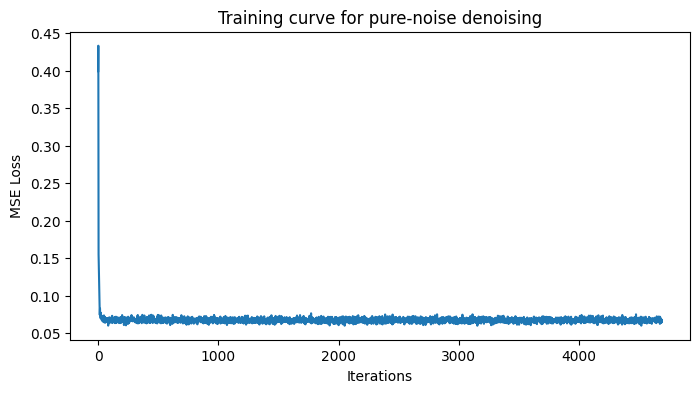

In [14]:
# Pure-noise training loss curve
plt.figure(figsize=(8, 4))
plt.plot(pure_train_losses)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Training curve for pure-noise denoising")
plt.show()

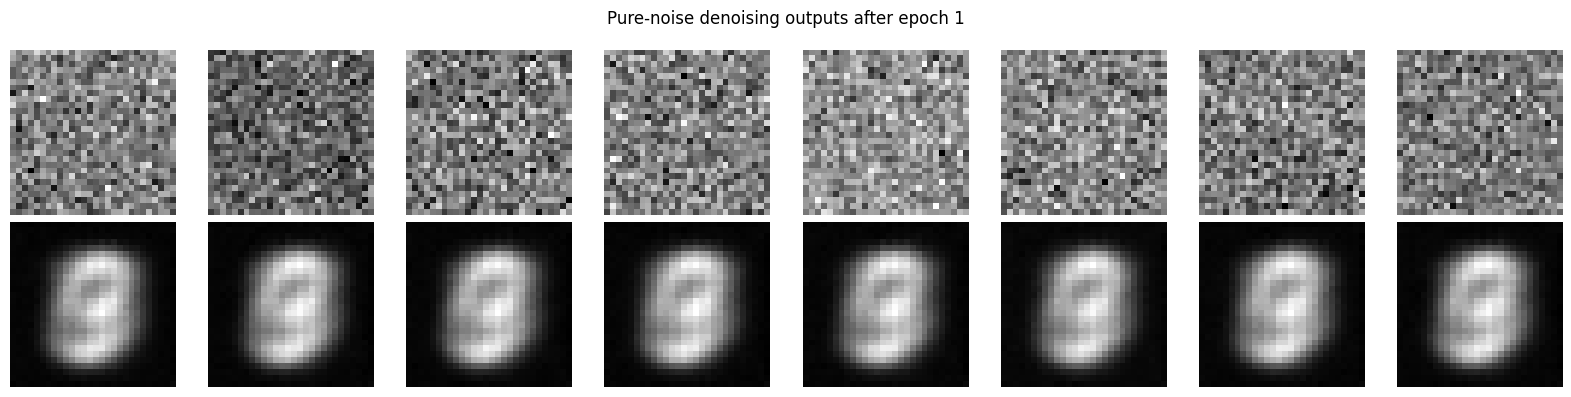

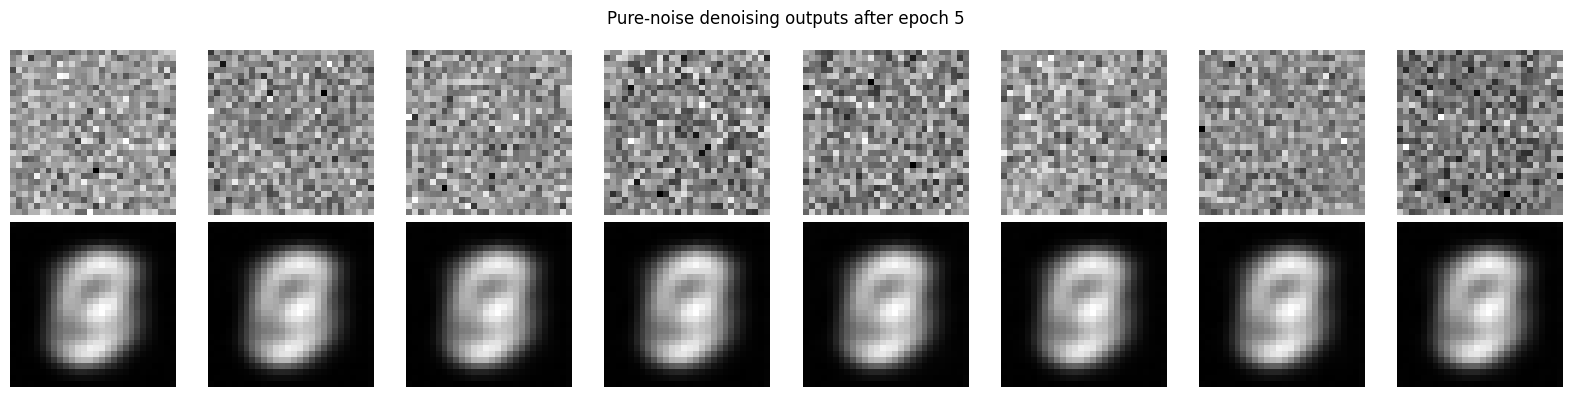

In [15]:
# Visualize pure-noise outputs after epoch 1 and 5
for ep in [1, 5]:
    sample_noise, sample_outputs = pure_snapshots[ep]

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axes[0, i].imshow(sample_noise[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel("Input noise", fontsize=12)

        axes[1, i].imshow(sample_outputs[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel("Output", fontsize=12)

    plt.suptitle(f"Pure-noise denoising outputs after epoch {ep}")
    plt.tight_layout()
    plt.show()

## A brief description of the patterns observed in the generated outputs and explanations for why they may exist.

**Observed pattern:** When trained to map pure Gaussian noise directly to MNIST images with an MSE loss, the model tends to generate blurry, average-looking digit shapes rather than sharp, diverse digits.

**Why this happens:** Since the input noise is independent of the target image, there is no meaningful one-to-one mapping from a specific noise sample to a specific digit. Under MSE loss, the optimal prediction becomes something close to the average of many plausible training images. As a result, the model learns a centroid-like output over the MNIST distribution, which often looks like fuzzy digit prototypes instead of clean individual digits.


# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [16]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()

        D = num_hiddens
        self.fc1_t = FCBlock(1, 2 * D)
        self.fc2_t = FCBlock(1, D)

        self.enc0 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2 * D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D)

        self.up1 = UpBlock(4 * D, D)
        self.up2 = UpBlock(2 * D, D)

        self.out_block = ConvBlock(2 * D, D)
        self.out = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        t = t.view(-1, 1)
        t1 = self.fc1_t(t).view(t.shape[0], -1, 1, 1)
        t2 = self.fc2_t(t).view(t.shape[0], -1, 1, 1)

        x0 = self.enc0(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)

        z = self.flatten(x2)
        z = self.unflatten(z)
        z = z * t1

        z = torch.cat([z, x2], dim=1)
        z = self.up1(z)
        z = z * t2

        z = torch.cat([z, x1], dim=1)
        z = self.up2(z)

        z = torch.cat([z, x0], dim=1)
        z = self.out_block(z)

        return self.out(z)

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [17]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()

    N = x_1.size(0)
    t = torch.rand(N, device=x_1.device)
    x_0 = torch.randn_like(x_1)

    t_expanded = t.view(N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    flow_pred = unet(x_t, t)
    flow_target = x_1 - x_0

    loss = torch.nn.functional.mse_loss(flow_pred, flow_target)
    return loss

In [18]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()

    torch.manual_seed(seed)
    N = 16 # default 16 images
    H, W = img_wh
    x_t = torch.randn(N, 1, H, W, device=next(unet.parameters()).device)
    dt = 1.0 / num_ts

    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((N,), t_val, device=x_t.device)
        flow = unet(x_t, t)
        x_t = x_t + flow * dt

    return x_t

In [19]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

Epoch 1/10: 100%|██████████| 938/938 [00:09<00:00, 100.35it/s]


Sampling after epoch 1...


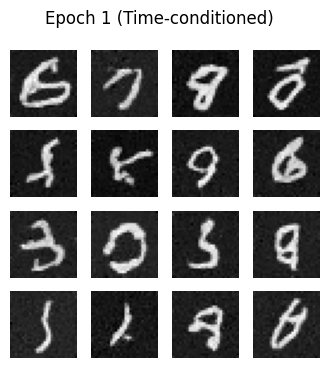

Epoch 5/10: 100%|██████████| 938/938 [00:09<00:00, 99.11it/s]


Sampling after epoch 5...


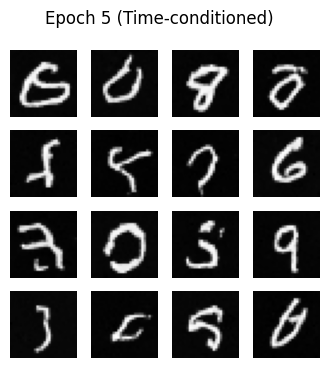

Epoch 10/10: 100%|██████████| 938/938 [00:09<00:00, 98.96it/s]


Sampling after epoch 10...


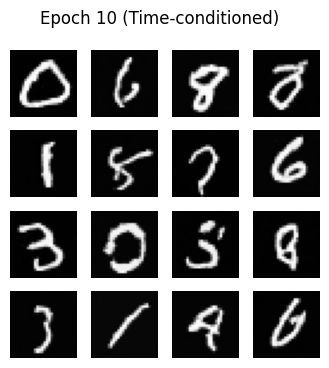

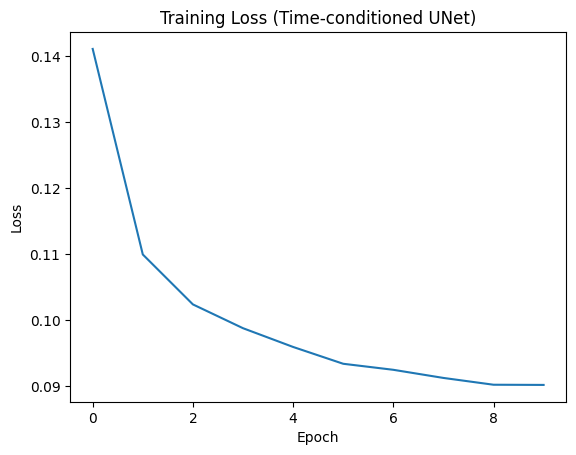

In [20]:
# Feel free to use code from part 1.2.1
# as they should be very similar
batch_size = 64
hidden_dim = 64
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = TimeConditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
fm = TimeConditionalFM(model, num_ts=50).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
gamma = (1.0 / num_epochs) ** 0.1
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        loss = fm(images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    scheduler.step()

    if epoch + 1 in [1, 5, 10]:
        print(f"Sampling after epoch {epoch+1}...")
        samples = fm.sample((28, 28), seed=42)
        fig, axes = plt.subplots(4, 4, figsize=(4, 4))
        for i in range(16):
            axes[i//4, i%4].imshow(samples[i].cpu().squeeze(), cmap='gray')
            axes[i//4, i%4].axis('off')
        plt.suptitle(f"Epoch {epoch+1} (Time-conditioned)")
        plt.show()

plt.plot(train_losses)
plt.title("Training Loss (Time-conditioned UNet)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Part 2.3: Sampling from the Time-conditioned UNet

The required samples for epochs 1, 5, and 10 are generated and displayed during training in the previous cell. Below, we additionally show final samples after full training for completeness.

Displaying final samples again for reference:


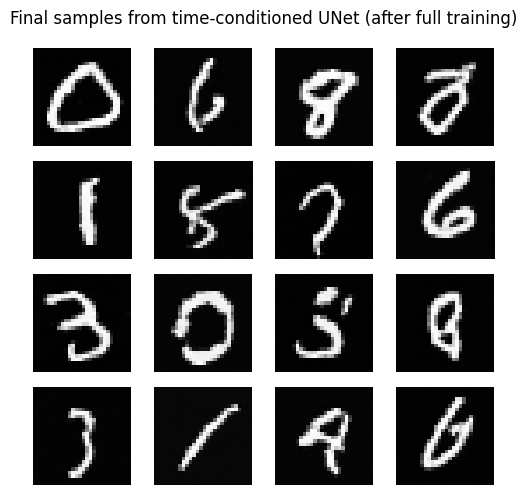

In [28]:
print("Displaying final samples again for reference:")
samples = fm.sample((28, 28), seed=42)

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for i in range(16):
    axes[i // 4, i % 4].imshow(samples[i].cpu().squeeze(), cmap='gray')
    axes[i // 4, i % 4].axis('off')

plt.suptitle("Final samples from time-conditioned UNet (after full training)")
plt.tight_layout()
plt.show()

# Part 2.4: Implementing a Class-conditioned UNet

In [22]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        D = num_hiddens
        self.num_classes = num_classes

        self.fc1_t = FCBlock(1, 2 * D)
        self.fc2_t = FCBlock(1, D)

        self.fc1_c = FCBlock(num_classes, 2 * D)
        self.fc2_c = FCBlock(num_classes, D)

        self.enc0 = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2 * D)

        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * D)

        self.up1 = UpBlock(4 * D, D)
        self.up2 = UpBlock(2 * D, D)

        self.out_block = ConvBlock(2 * D, D)
        self.out = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        N = x.size(0)
        t = t.view(N, 1)

        c_onehot = torch.nn.functional.one_hot(c, num_classes=self.num_classes).float()
        if mask is not None:
            c_onehot = c_onehot * mask.view(N, 1)

        t1 = self.fc1_t(t).view(N, -1, 1, 1)
        t2 = self.fc2_t(t).view(N, -1, 1, 1)

        c1 = self.fc1_c(c_onehot).view(N, -1, 1, 1)
        c2 = self.fc2_c(c_onehot).view(N, -1, 1, 1)

        x0 = self.enc0(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)

        z = self.flatten(x2)
        z = self.unflatten(z)
        z = c1 * z + t1

        z = torch.cat([z, x2], dim=1)
        z = self.up1(z)
        z = c2 * z + t2

        z = torch.cat([z, x1], dim=1)
        z = self.up2(z)

        z = torch.cat([z, x0], dim=1)
        z = self.out_block(z)

        return self.out(z)

In [23]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()

    N = x_1.size(0)
    t = torch.rand(N, device=x_1.device)
    x_0 = torch.randn_like(x_1)

    t_expanded = t.view(N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    mask = (torch.rand(N, device=x_1.device) > p_uncond).float()

    flow_pred = unet(x_t, c, t, mask)
    flow_target = x_1 - x_0

    loss = torch.nn.functional.mse_loss(flow_pred, flow_target)
    return loss

In [24]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()

    torch.manual_seed(seed)
    N = c.size(0)
    H, W = img_wh
    x_t = torch.randn(N, 1, H, W, device=next(unet.parameters()).device)
    dt = 1.0 / num_ts

    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((N,), t_val, device=x_t.device)

        mask_cond = torch.ones(N, device=x_t.device)
        flow_cond = unet(x_t, c, t, mask_cond)

        mask_uncond = torch.zeros(N, device=x_t.device)
        flow_uncond = unet(x_t, c, t, mask_uncond)

        flow_guided = flow_uncond + guidance_scale * (flow_cond - flow_uncond)
        x_t = x_t + flow_guided * dt

    return x_t

In [25]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

Epoch 1/10: 100%|██████████| 938/938 [00:10<00:00, 92.85it/s]


Sampling after epoch 1...


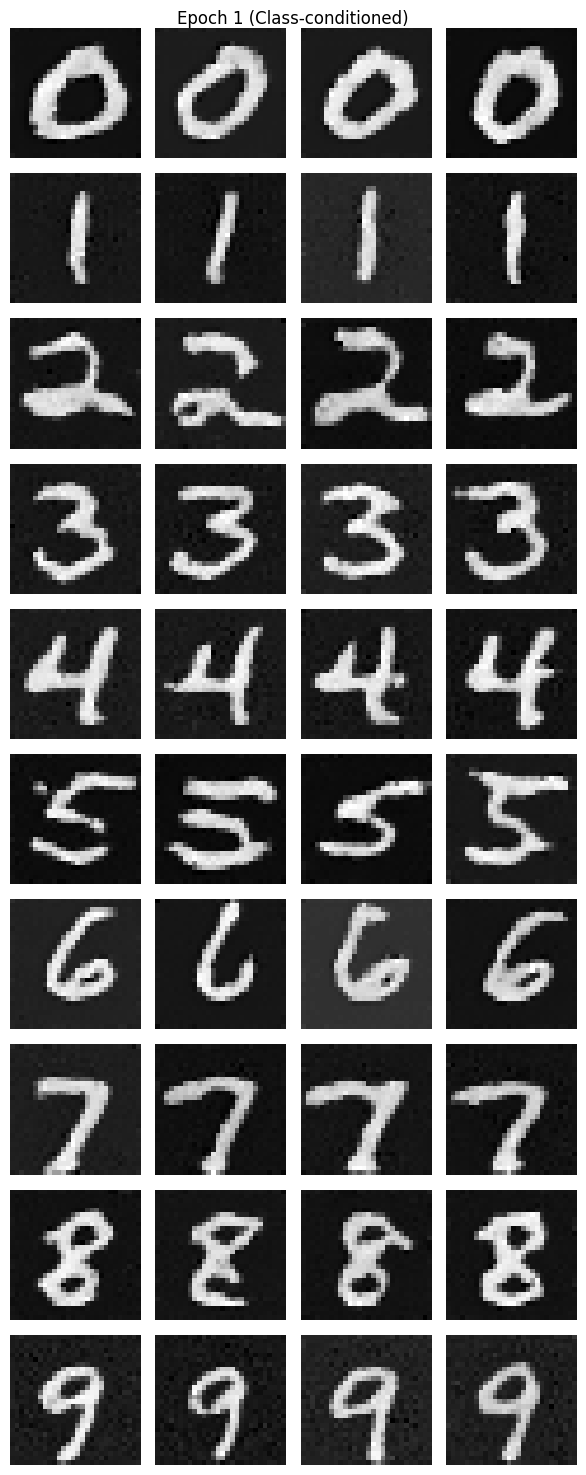

Epoch 5/10: 100%|██████████| 938/938 [00:09<00:00, 93.94it/s]


Sampling after epoch 5...


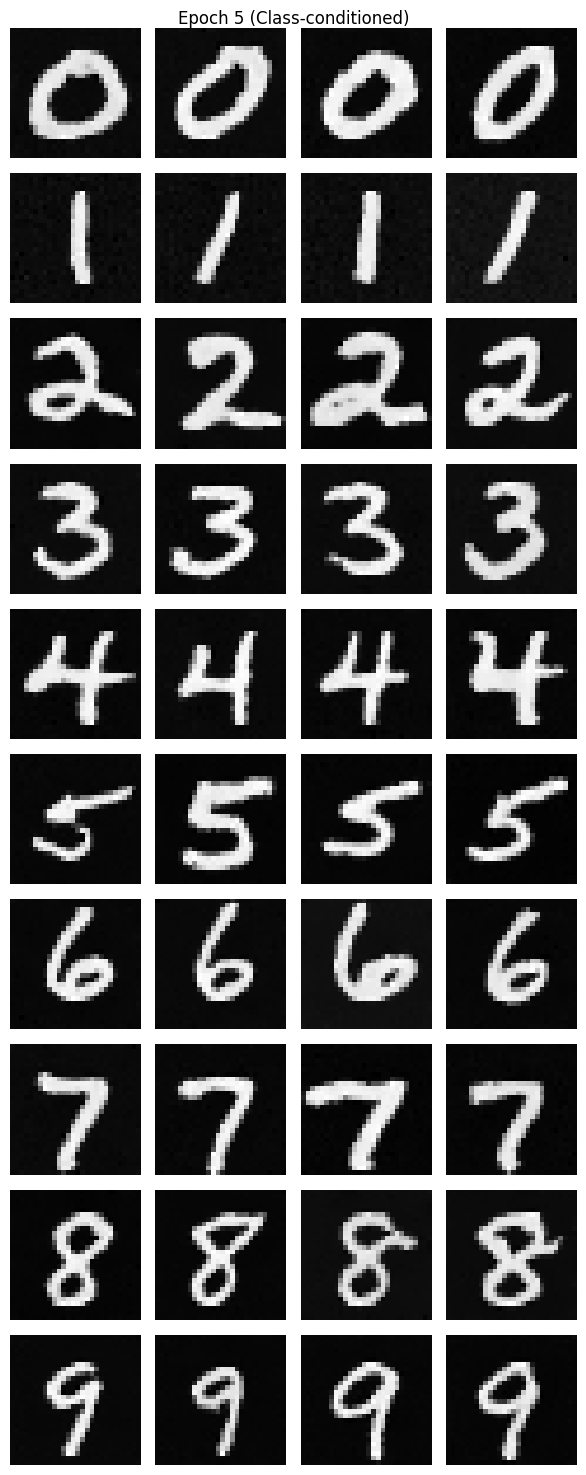

Epoch 10/10: 100%|██████████| 938/938 [00:10<00:00, 92.66it/s]


Sampling after epoch 10...


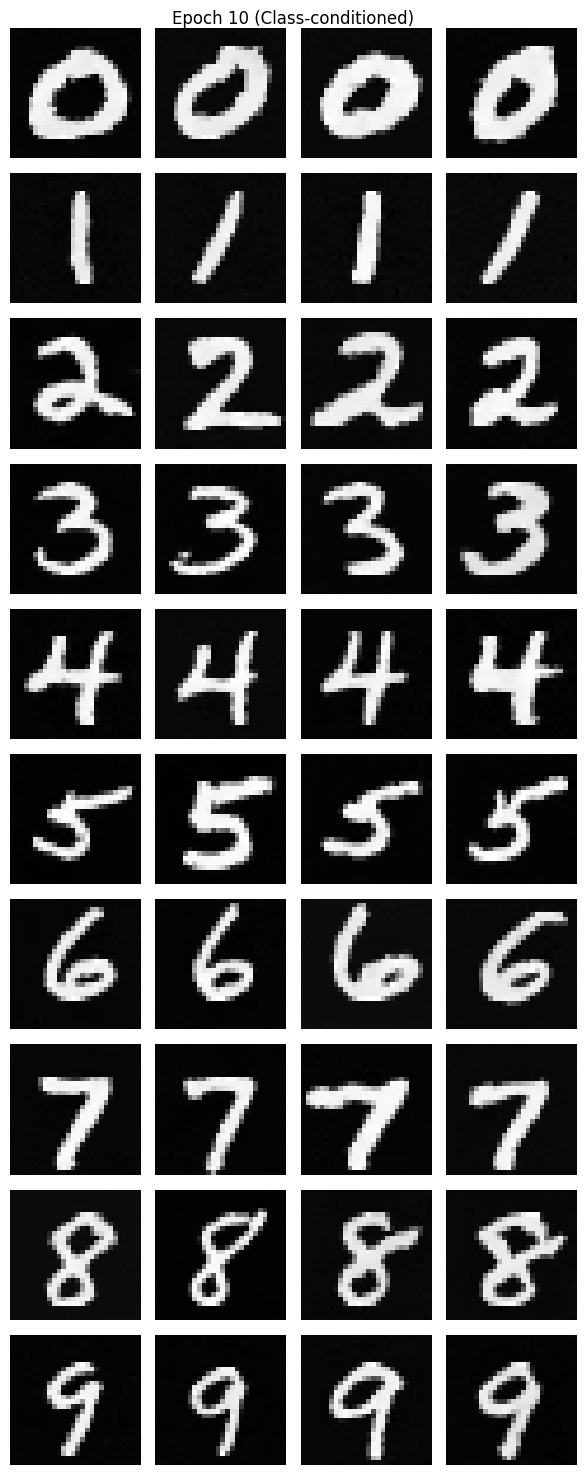

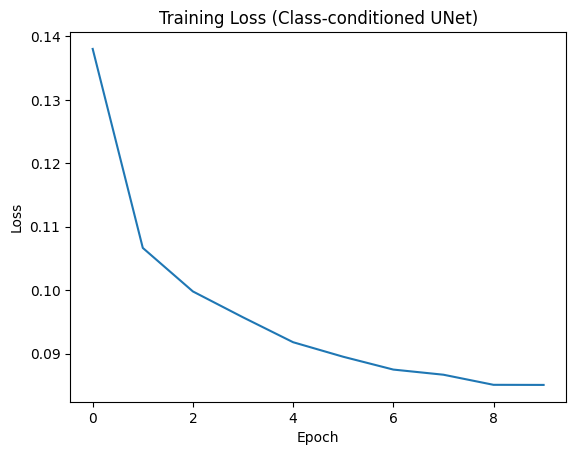

In [26]:
# Feel free to use code from part 1.2.1
# as they should be very similar

batch_size = 64
hidden_dim = 64
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model_class = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)
fm_class = ClassConditionalFM(model_class, num_ts=50, p_uncond=0.1).to(device)

optimizer_class = torch.optim.Adam(model_class.parameters(), lr=1e-3)
gamma = (1.0 / num_epochs) ** 0.1
scheduler_class = torch.optim.lr_scheduler.ExponentialLR(optimizer_class, gamma=gamma)

train_losses_class = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)
        loss = fm_class(images, labels)

        optimizer_class.zero_grad()
        loss.backward()
        optimizer_class.step()

        epoch_loss += loss.item()

    train_losses_class.append(epoch_loss / len(train_loader))
    scheduler_class.step()

    if epoch + 1 in [1, 5, 10]:
        print(f"Sampling after epoch {epoch+1}...")
        classes = torch.tensor([i for i in range(10) for _ in range(4)], device=device)
        samples = fm_class.sample(classes, (28, 28), guidance_scale=5.0, seed=42)
        fig, axes = plt.subplots(10, 4, figsize=(6, 15))
        for i in range(40):
            axes[i//4, i%4].imshow(samples[i].cpu().squeeze(), cmap='gray')
            axes[i//4, i%4].axis('off')
        plt.suptitle(f"Epoch {epoch+1} (Class-conditioned)")
        plt.tight_layout()
        plt.show()

plt.plot(train_losses_class)
plt.title("Training Loss (Class-conditioned UNet)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Part 2.6: Sampling from the Class-conditioned UNet

Sampling already handled in training loop.
Running ablation study without scheduler...
Running no-scheduler ablation...


No-Scheduler Epoch 10/10: 100%|██████████| 938/938 [00:10<00:00, 91.96it/s]


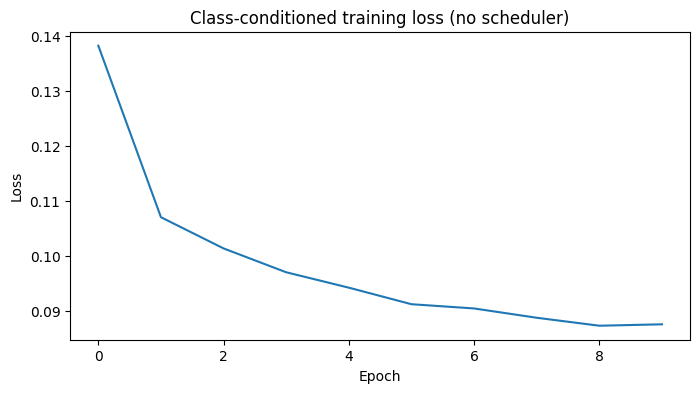

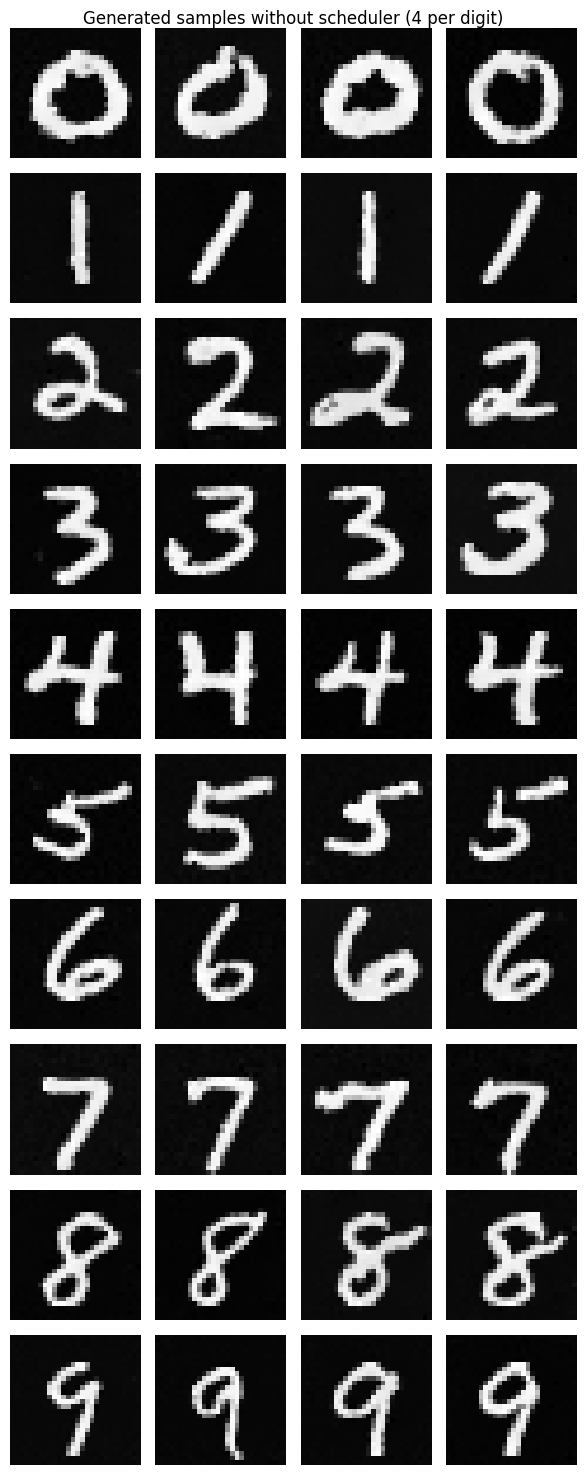

In [27]:
# Sampling from the UNet
print("Sampling already handled in training loop.")
print("Running ablation study without scheduler...")
print("Running no-scheduler ablation...")

model_no_sched = ClassConditionalUNet(
    in_channels=1,
    num_classes=10,
    num_hiddens=hidden_dim
).to(device)

fm_no_sched = ClassConditionalFM(model_no_sched, num_ts=50, p_uncond=0.1).to(device)

# Compensate for removing scheduler by lowering lr
optimizer_no_sched = torch.optim.Adam(model_no_sched.parameters(), lr=1e-3)

num_epochs_no_sched = 10
train_losses_no_sched = []

for epoch in range(num_epochs_no_sched):
    epoch_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"No-Scheduler Epoch {epoch+1}/{num_epochs_no_sched}"):
        images, labels = images.to(device), labels.to(device)

        loss = fm_no_sched(images, labels)

        optimizer_no_sched.zero_grad()
        loss.backward()
        optimizer_no_sched.step()

        epoch_loss += loss.item()

    train_losses_no_sched.append(epoch_loss / len(train_loader))

plt.figure(figsize=(8, 4))
plt.plot(train_losses_no_sched)
plt.title("Class-conditioned training loss (no scheduler)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

classes = torch.tensor([i for i in range(10) for _ in range(4)], device=device)
samples_no_sched = fm_no_sched.sample(classes, (28, 28), guidance_scale=5.0, seed=42)

fig, axes = plt.subplots(10, 4, figsize=(6, 15))
for i in range(40):
    axes[i // 4, i % 4].imshow(samples_no_sched[i].cpu().squeeze(), cmap='gray')
    axes[i // 4, i % 4].axis('off')

plt.suptitle("Generated samples without scheduler (4 per digit)")
plt.tight_layout()
plt.show()

## Can we get rid of the annoying learning rate scheduler?
To remove the exponential learning rate scheduler while maintaining similar performance, I reduced the learning rate from a more aggressive setting to **1e-3** and kept the rest of the training setup unchanged. This makes optimization more stable without needing explicit decay, while still allowing the class-conditioned model to converge to reasonable digit generations.
